# Red Wine Quality Analysis
**Multivariate Statistical Analysis & Predictive Modelling**



In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, classification_report,
                             confusion_matrix, accuracy_score)
from sklearn.inspection import permutation_importance

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = "RdYlGn"

---
## 2. Load & Clean Data

In [5]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
# Check missing values and duplicates
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

Missing values: 0
Duplicate rows: 240


In [9]:
df = df.drop_duplicates().reset_index(drop=True)
FEATURES = [col for col in df.columns if col != "quality"]
TARGET   = "quality"
print(f"Clean shape: {df.shape}")

Clean shape: (1359, 12)


---
## 3. EDA

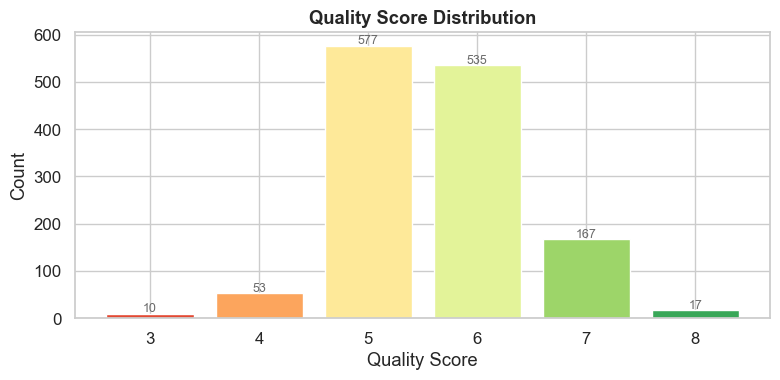

In [10]:
counts = df["quality"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values,
        color=sns.color_palette(PALETTE, len(counts)), edgecolor="white")
for q, c in counts.items():
    plt.text(q, c + 4, str(c), ha="center", fontsize=9, color="dimgray")
plt.title("Quality Score Distribution", fontweight="bold")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

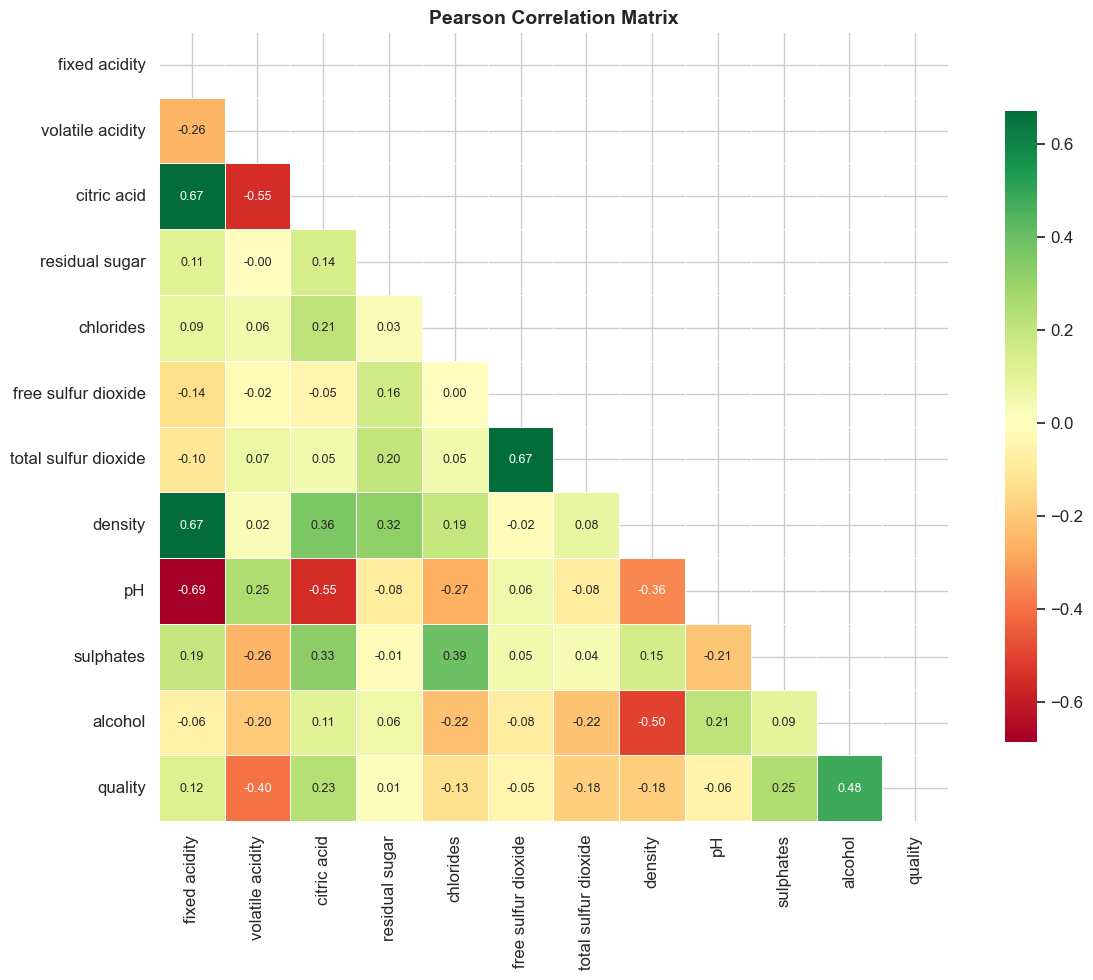

In [11]:
corr = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 9})
ax.set_title("Pearson Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

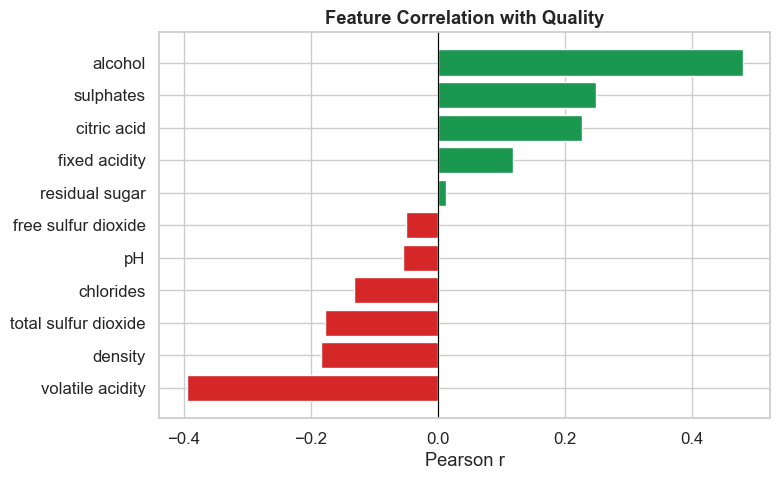

In [12]:
quality_corr = corr["quality"].drop("quality").sort_values()

plt.figure(figsize=(8, 5))
plt.barh(quality_corr.index, quality_corr.values,
         color=["#d62728" if v < 0 else "#1a9850" for v in quality_corr.values],
         edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Quality", fontweight="bold")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_14732\3307747093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y="alcohol",          data=df, palette=PALETTE, ax=axes[0])
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_14732\3307747093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y="volatile acidity", data=df, palette=PALETTE, ax=axes[1])


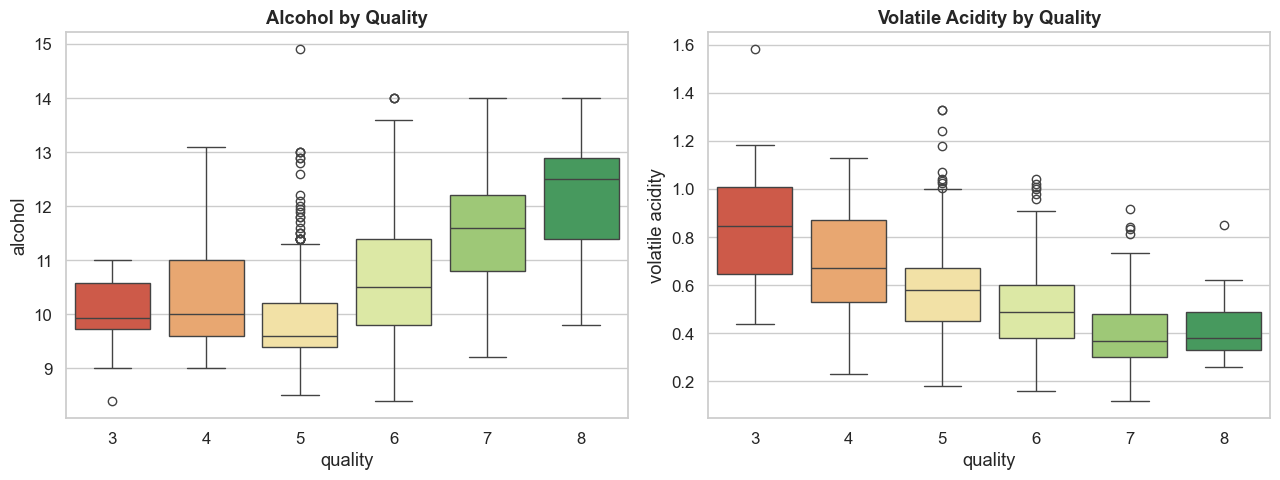

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x="quality", y="alcohol",          data=df, palette=PALETTE, ax=axes[0])
sns.boxplot(x="quality", y="volatile acidity", data=df, palette=PALETTE, ax=axes[1])
axes[0].set_title("Alcohol by Quality",          fontweight="bold")
axes[1].set_title("Volatile Acidity by Quality", fontweight="bold")
plt.tight_layout()
plt.show()

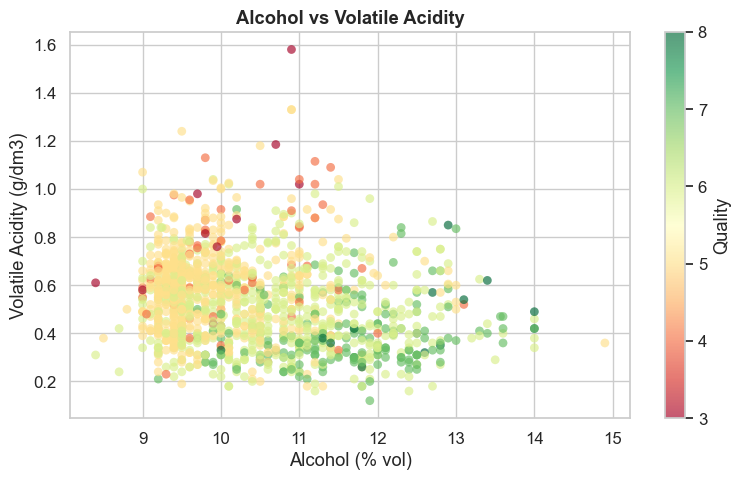

In [14]:
plt.figure(figsize=(8, 5))
sc = plt.scatter(df["alcohol"], df["volatile acidity"],
                 c=df["quality"], cmap=PALETTE, alpha=0.65, s=40, edgecolors="none")
plt.colorbar(sc, label="Quality")
plt.xlabel("Alcohol (% vol)")
plt.ylabel("Volatile Acidity (g/dm3)")
plt.title("Alcohol vs Volatile Acidity", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Outlier Detection (IQR)

In [15]:
iqr_outliers = {}
for col in FEATURES:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers[col] = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

pd.Series(iqr_outliers, name="Outlier Count").sort_values(ascending=False)

residual sugar          126
chlorides                87
sulphates                55
total sulfur dioxide     45
fixed acidity            41
density                  35
pH                       28
free sulfur dioxide      26
volatile acidity         19
alcohol                  12
citric acid               1
Name: Outlier Count, dtype: int64

---
## 5. Principal Component Analysis

In [16]:
scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(df[FEATURES])

pca_full   = PCA(n_components=len(FEATURES), random_state=42)
pca_full.fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1
print(f"Components to explain 95% variance: {n_95}")

Components to explain 95% variance: 9


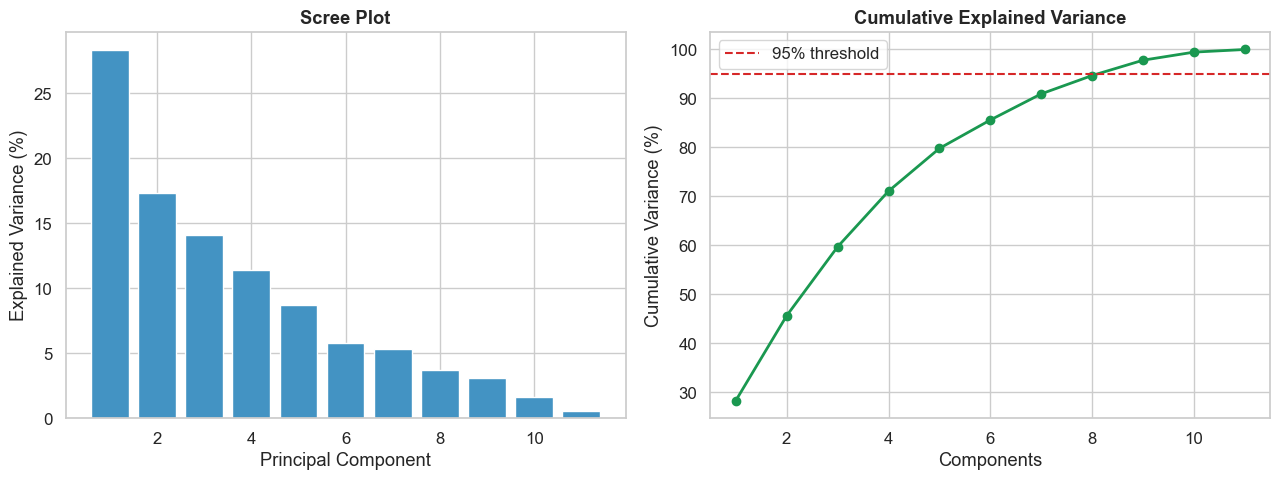

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(FEATURES)+1), pca_full.explained_variance_ratio_ * 100,
            color="#4393c3", edgecolor="white")
axes[0].set(xlabel="Principal Component", ylabel="Explained Variance (%)", title="Scree Plot")
axes[0].set_title("Scree Plot", fontweight="bold")

axes[1].plot(range(1, len(FEATURES)+1), cumulative * 100, "o-", color="#1a9850", linewidth=2)
axes[1].axhline(95, color="#d62728", linestyle="--", label="95% threshold")
axes[1].set(xlabel="Components", ylabel="Cumulative Variance (%)")
axes[1].set_title("Cumulative Explained Variance", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

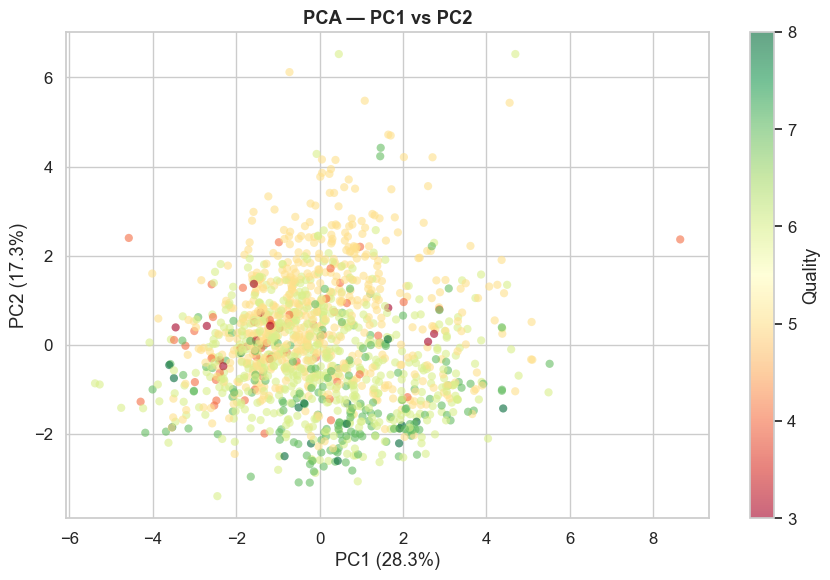

In [18]:
pca2  = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                 c=df["quality"], cmap=PALETTE, alpha=0.6, s=35, edgecolors="none")
plt.colorbar(sc, label="Quality")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA — PC1 vs PC2", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Prepare Data for Modelling

In [19]:
df["quality_label"] = (df["quality"] >= 6).astype(int)
df["quality_label"].value_counts().rename({0: "Low (<=5)", 1: "High (>=6)"})

quality_label
High (>=6)    719
Low (<=5)     640
Name: count, dtype: int64

In [20]:
X = df[FEATURES]
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["quality_label"])

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 1087  |  Test: 272


---
## 7. Train All Regression Models

In [21]:
models = {
    "Linear Regression" : LinearRegression(),
    "Ridge"             : Ridge(alpha=1.0),
    "Lasso"             : Lasso(alpha=0.01),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, max_depth=4, random_state=42),
    "SVR"               : SVR(kernel="rbf", C=5, epsilon=0.2),
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    print(f"{name} — trained")

Linear Regression — trained
Ridge — trained
Lasso — trained
Random Forest — trained
Gradient Boosting — trained
SVR — trained


---
## 8. Model Comparison

In [22]:
rows = []
for name, model in models.items():
    preds = model.predict(X_test_s)
    rows.append({
        "Model" : name,
        "RMSE"  : round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        "MAE"   : round(mean_absolute_error(y_test, preds), 4),
        "R2"    : round(r2_score(y_test, preds), 4),
        "CV R2" : round(cross_val_score(model, X_train_s, y_train, cv=5, scoring="r2", n_jobs=-1).mean(), 4),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")
metrics_df.sort_values("R2", ascending=False)

,RMSE,MAE,R2,CV R2
Model,,,,
Random Forest,0.6813,0.5236,0.4219,0.3495
Linear Regression,0.7034,0.5474,0.3839,0.3181
Ridge,0.7034,0.5475,0.3837,0.3182
SVR,0.7036,0.5445,0.3836,0.3235
Lasso,0.7068,0.5515,0.3778,0.3189
Gradient Boosting,0.7071,0.5470,0.3772,0.3093


In [23]:
best_name  = metrics_df["R2"].idxmax()
best_model = models[best_name]
best_preds = best_model.predict(X_test_s)
print(f"Best: {best_name}  |  R2 = {metrics_df.loc[best_name, 'R2']}")

Best: Random Forest  |  R2 = 0.4219


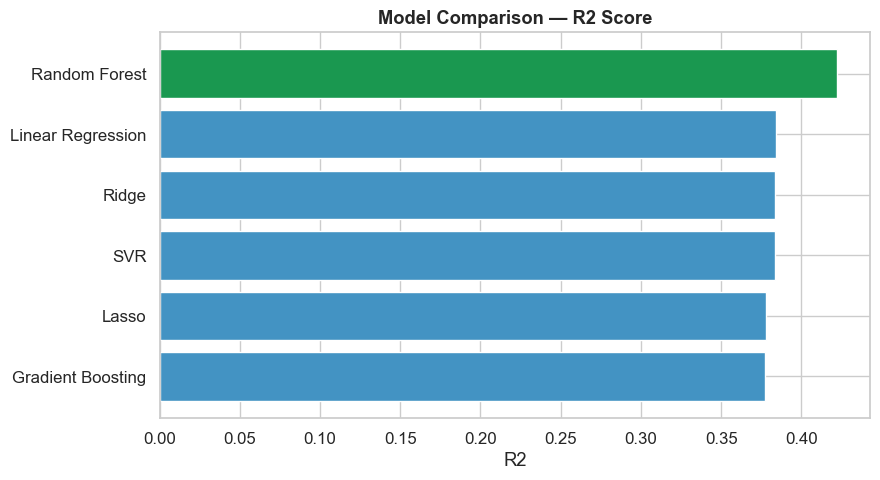

In [24]:
r2_sorted = metrics_df["R2"].sort_values()

plt.figure(figsize=(9, 5))
plt.barh(r2_sorted.index, r2_sorted.values,
         color=["#1a9850" if n == best_name else "#4393c3" for n in r2_sorted.index],
         edgecolor="white")
plt.title("Model Comparison — R2 Score", fontweight="bold")
plt.xlabel("R2")
plt.tight_layout()
plt.show()

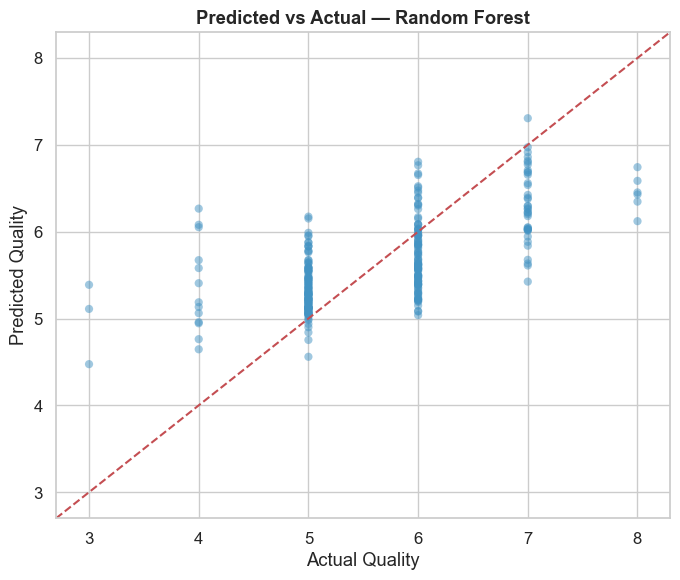

In [26]:
lims = [y_test.min() - 0.3, y_test.max() + 0.3]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.5, color="#4393c3", s=35, edgecolors="none")
plt.plot(lims, lims, "r--", linewidth=1.5)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title(f"Predicted vs Actual — {best_name}", fontweight="bold")
plt.tight_layout()
plt.show()

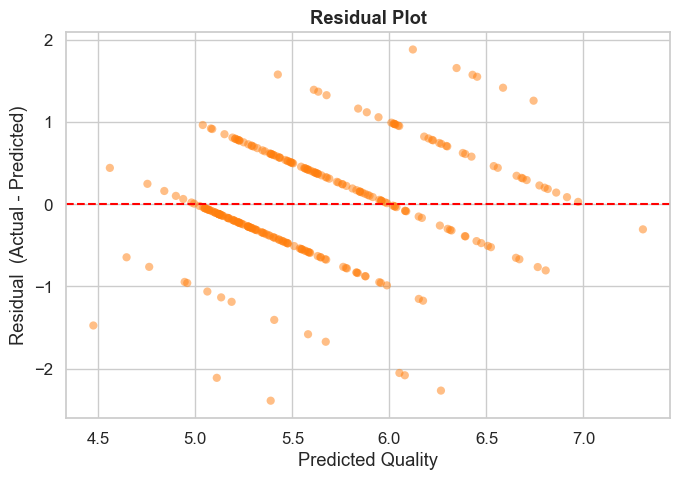

In [27]:
residuals = y_test - best_preds

plt.figure(figsize=(7, 5))
plt.scatter(best_preds, residuals, alpha=0.5, color="#ff7f0e", s=35, edgecolors="none")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Quality")
plt.ylabel("Residual  (Actual - Predicted)")
plt.title("Residual Plot", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 10. Feature Importance

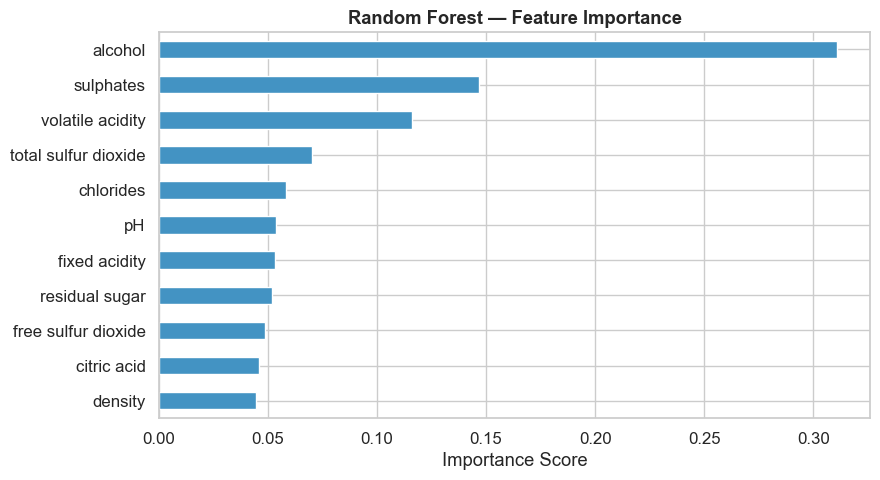

In [30]:
rf_imp = pd.Series(models["Random Forest"].feature_importances_,
                   index=FEATURES).sort_values()

plt.figure(figsize=(9, 5))
rf_imp.plot(kind="barh", color="#4393c3", edgecolor="white")
plt.title("Random Forest — Feature Importance", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

---
## 11. Binary Classification 

In [31]:
y_bin = df["quality_label"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

sc_clf     = StandardScaler()
Xb_train_s = sc_clf.fit_transform(Xb_train)
Xb_test_s  = sc_clf.transform(Xb_test)

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(Xb_train_s, yb_train)
yb_pred = clf.predict(Xb_test_s)

In [32]:
acc = accuracy_score(yb_test, yb_pred)
print(f"Accuracy: {acc*100:.2f}%\n")
print(classification_report(yb_test, yb_pred, target_names=["Low (<=5)", "High (>=6)"]))

Accuracy: 75.74%

              precision    recall  f1-score   support

   Low (<=5)       0.72      0.78      0.75       128
  High (>=6)       0.79      0.74      0.76       144

    accuracy                           0.76       272
   macro avg       0.76      0.76      0.76       272
weighted avg       0.76      0.76      0.76       272



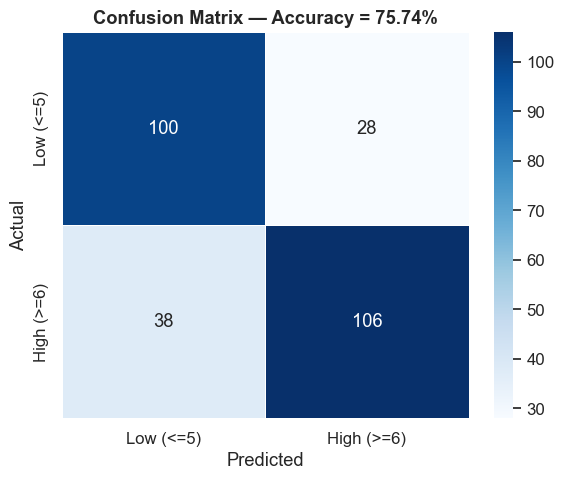

In [33]:
cm = confusion_matrix(yb_test, yb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low (<=5)", "High (>=6)"],
            yticklabels=["Low (<=5)", "High (>=6)"],
            linewidths=0.5)
plt.title(f"Confusion Matrix — Accuracy = {acc:.2%}", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()